In [77]:
import os
os.makedirs("outputs", exist_ok=True)

import torch
import torchvision
from torchvision import models
from torchvision.models import ResNet18_Weights
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version:     {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")

Using device: cuda
PyTorch version:     2.10.0+cu128
TorchVision version: 0.25.0+cu128


## PyTorch Tensors

## Tensor Question 1

In [78]:
a = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])

b = torch.zeros(2, 3)
c = torch.ones(4)

for name, tensor in [("a", a), ("b", b), ("c", c)]:
    print(f"{name}:")
    print(tensor)
    print(f"shape: {tensor.shape}")
    print(f"dtype: {tensor.dtype}")
    print(f"device: {tensor.device}")
    print()

a:
tensor([[1., 2., 3.],
        [4., 5., 6.]])
shape: torch.Size([2, 3])
dtype: torch.float32
device: cpu

b:
tensor([[0., 0., 0.],
        [0., 0., 0.]])
shape: torch.Size([2, 3])
dtype: torch.float32
device: cpu

c:
tensor([1., 1., 1., 1.])
shape: torch.Size([4])
dtype: torch.float32
device: cpu



## Tensor Question 2

In [79]:
x = torch.tensor([1.0, 4.0, 9.0, 16.0, 25.0])

print("Square root:")
print(torch.sqrt(x))

print("\nSum:")
print(x.sum())

print("\nMean:")
print(x.mean())

print("\nArgmax:")
print(x.argmax())

Square root:
tensor([1., 2., 3., 4., 5.])

Sum:
tensor(55.)

Mean:
tensor(11.)

Argmax:
tensor(4)


## Tensor Question 3

In [80]:
a_gpu = a.to(device)
print(f"a_gpu device: {a_gpu.device}")

a_back = a_gpu.cpu()
a_numpy = a_back.numpy()

print(f"numpy type: {type(a_numpy)}")
print(f"numpy values:\n{a_numpy}")

a_gpu device: cuda:0
numpy type: <class 'numpy.ndarray'>
numpy values:
[[1. 2. 3.]
 [4. 5. 6.]]


## Tensor Question 4

In [81]:
t = torch.arange(24).float()

t_4_6 = t.reshape(4, 6)
print("Shape after reshape to (4, 6):")
print(t_4_6.shape)

t_2_3_4 = t.reshape(2, 3, 4)
print("\nShape after reshape to (2, 3, 4):")
print(t_2_3_4.shape)

t_batch = t_4_6.unsqueeze(0)
print("\nShape after adding new dimension at position 0:")
print(t_batch.shape)

Shape after reshape to (4, 6):
torch.Size([4, 6])

Shape after reshape to (2, 3, 4):
torch.Size([2, 3, 4])

Shape after adding new dimension at position 0:
torch.Size([1, 4, 6])


## Tensor Question 5

In [82]:
np_a = np.array([[1.0, 2.0], [3.0, 4.0]])
np_b = np.array([[5.0, 6.0], [7.0, 8.0]])

t_a = torch.tensor(np_a, dtype=torch.float32)
t_b = torch.tensor(np_b, dtype=torch.float32)

np_result = np_a @ np_b
torch_result = t_a @ t_b

print("NumPy result:")
print(np_result)

print("\nPyTorch result:")
print(torch_result)

print("\nOutputs match:")
print(np.allclose(np_result, torch_result.numpy()))

NumPy result:
[[19. 22.]
 [43. 50.]]

PyTorch result:
tensor([[19., 22.],
        [43., 50.]])

Outputs match:
True


## Pretrained Models

## Model Question 1

In [83]:
weights = ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters:     11,689,512
Trainable parameters: 11,689,512


## Model Question 2

In [84]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Model Question 3

In [85]:
model = model.to(device)
model.eval()
print("Model ready for inference.")

Model ready for inference.


## Model Question 4

In [86]:
preprocess = weights.transforms()
print(preprocess)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


## Running Inference

## Setup Image Helper

In [87]:
from pathlib import Path
from PIL import Image
import random

DATA_DIR = Path("/kaggle/input")
LABELS = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

def load_sample_image(label):
    all_images = (
        list(DATA_DIR.rglob("*.jpg")) +
        list(DATA_DIR.rglob("*.jpeg")) +
        list(DATA_DIR.rglob("*.png"))
    )

    paths = [
        p for p in all_images
        if label.lower() in str(p.parent).lower()
    ]

    print("Label:", label)
    print("Images found:", len(paths))

    if len(paths) == 0:
        print("Available image folders:")
        folders = sorted(set(str(p.parent) for p in all_images))
        for folder in folders[:30]:
            print(folder)
        raise FileNotFoundError(f"No images found for {label}")

    img_path = random.choice(paths)
    return Image.open(img_path).convert("RGB"), img_path.name

## ImageNet Classes

In [88]:
imagenet_classes = weights.meta["categories"]

print(f"Number of classes: {len(imagenet_classes)}")
print(f"First 5 labels: {imagenet_classes[:5]}")

Number of classes: 1000
First 5 labels: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']


### Inference Question 1

In [89]:
def get_top5_predictions(model, preprocess, image, device, class_labels):
    input_tensor = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)

    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    top_probs, top_indices = torch.topk(probabilities, 5)

    results = []

    for prob, index in zip(top_probs, top_indices):
        class_name = class_labels[index.item()]
        results.append((class_name, prob.item()))

    return results

In [90]:
img, img_name = load_sample_image("mountain")
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

print(f"\nTop-5 predictions for '{img_name}':")

for class_name, prob in preds:
    print(f"  {class_name:30s}  {prob:.4f}")

Label: mountain
Images found: 3037

Top-5 predictions for '22734.jpg':
  alp                             0.5964
  valley                          0.1621
  mountain bike                   0.0923
  promontory                      0.0287
  cliff                           0.0281


### Inference Question 2

In [91]:
for label in LABELS:
    img, img_name = load_sample_image(label)
    preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)[:3]

    print(f"\n[{label}]  {img_name}")

    for class_name, prob in preds:
        print(f"  {class_name:30s}  {prob:.4f}")

Label: buildings
Images found: 2628

[buildings]  5186.jpg
  castle                          0.5064
  church                          0.3782
  monastery                       0.0231
Label: forest
Images found: 2745

[forest]  2953.jpg
  mountain tent                   0.0941
  mountain bike                   0.0883
  valley                          0.0665
Label: glacier
Images found: 2957

[glacier]  24.jpg
  alp                             0.9536
  valley                          0.0243
  mountain tent                   0.0088
Label: mountain
Images found: 3037

[mountain]  9330.jpg
  valley                          0.6118
  alp                             0.2245
  volcano                         0.0792
Label: sea
Images found: 2784

[sea]  9745.jpg
  seashore                        0.5747
  promontory                      0.3233
  breakwater                      0.0302
Label: street
Images found: 2883

[street]  3184.jpg
  prison                          0.4219
  passenger car       

### Inference Question 3

In [92]:
img, _ = load_sample_image("forest")
input_tensor = preprocess(img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(input_tensor)

probs = torch.nn.functional.softmax(logits[0], dim=0)

print(f"Logit  range: min={logits.min():.2f}, max={logits.max():.2f}")
print(f"Prob   range: min={probs.min():.6f}, max={probs.max():.4f}")
print(f"Probs sum to: {probs.sum():.6f}")
print(f"Top prediction: {imagenet_classes[probs.argmax().item()]}  ({probs.max():.4f})")

Label: forest
Images found: 2745
Logit  range: min=-4.69, max=6.29
Prob   range: min=0.000001, max=0.0849
Probs sum to: 1.000000
Top prediction: mountain tent  (0.0849)


### Inference Question 4

Label: mountain
Images found: 3037


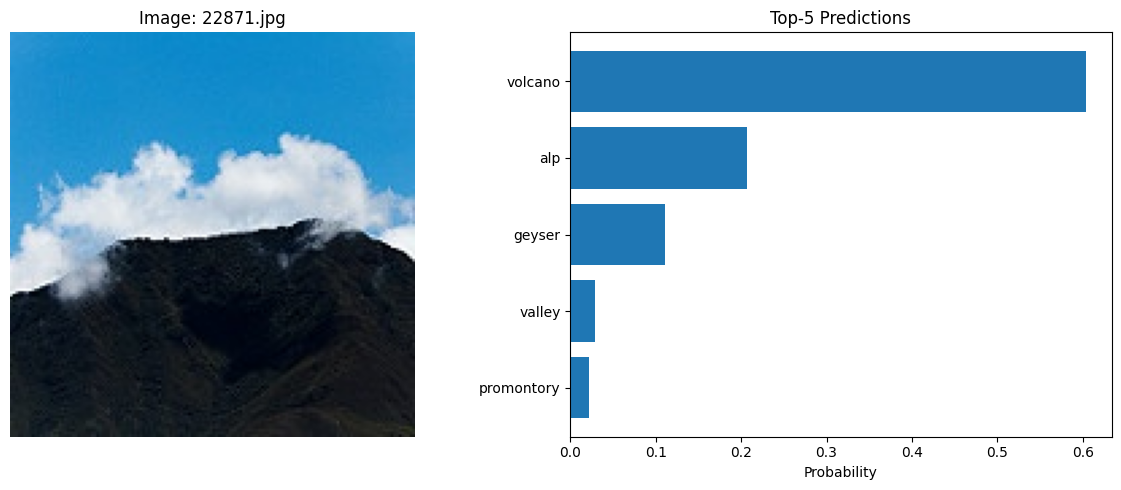

Saved visualization to outputs/warmup_inference_viz.png


In [93]:
img, img_name = load_sample_image("mountain")
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

class_names = [item[0] for item in preds]
probabilities = [item[1] for item in preds]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img)
axes[0].set_title(f"Image: {img_name}")
axes[0].axis("off")

axes[1].barh(class_names, probabilities)
axes[1].set_xlabel("Probability")
axes[1].set_title("Top-5 Predictions")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("outputs/warmup_inference_viz.png")
plt.show()

print("Saved visualization to outputs/warmup_inference_viz.png")